In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
!git clone https://github.com/Raadhesh-28/Minor-Project.git
%cd Minor-Project

Cloning into 'Minor-Project'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 62 (delta 25), reused 49 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 18.69 KiB | 18.69 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/Minor-Project


In [ ]:
!pip install torch torchvision scikit-learn pillow tqdm kaggle

In [ ]:
import json

kaggle_config = {
    "username": "raadhesh28",
    "key": "KGAT_8d105667eb03cfabc7a70934c458ef8c"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d ajg117/indian-paintings-dataset

Dataset URL: https://www.kaggle.com/datasets/ajg117/indian-paintings-dataset
License(s): MIT
100% 355M/355M [00:20<00:00, 17.8MB/s]



In [ ]:
!unzip indian-paintings-dataset.zip

Archive:  indian-paintings-dataset.zip
  inflating: LICENSE                 
  inflating: classes.csv             
  inflating: gond painting/gond0.jpeg  
  inflating: gond painting/gond1.jpeg  
  inflating: gond painting/gond10.jpg  
  inflating: gond painting/gond100.jpeg  
  inflating: gond painting/gond11.jpg  
  inflating: gond painting/gond12.png  
  inflating: gond painting/gond13.jpg  
  inflating: gond painting/gond14.jpg  
  inflating: gond painting/gond15.jpg  
  inflating: gond painting/gond16.jpg  
  inflating: gond painting/gond17.jpg  
  inflating: gond painting/gond18.jpeg  
  inflating: gond painting/gond19.png  
  inflating: gond painting/gond2.jpg  
  inflating: gond painting/gond20.jpg  
  inflating: gond painting/gond21.jpeg  
  inflating: gond painting/gond22.jpg  
  inflating: gond painting/gond23.jpg  
  inflating: gond painting/gond24.webp  
  inflating: gond painting/gond25.jpg  
  inflating: gond painting/gond26.jpg  
  inflating: gond painting/gond27.jpg  
 

In [ ]:
!mkdir -p data/raw

In [ ]:
!ls data/raw

'gond painting'      'kerala mural'	    'pichwai painting'
'kalighat painting'  'madhubani painting'   'warli painting'
'kangra painting'    'mandana art drawing'


Success! Grid saved to dataset_samples.png


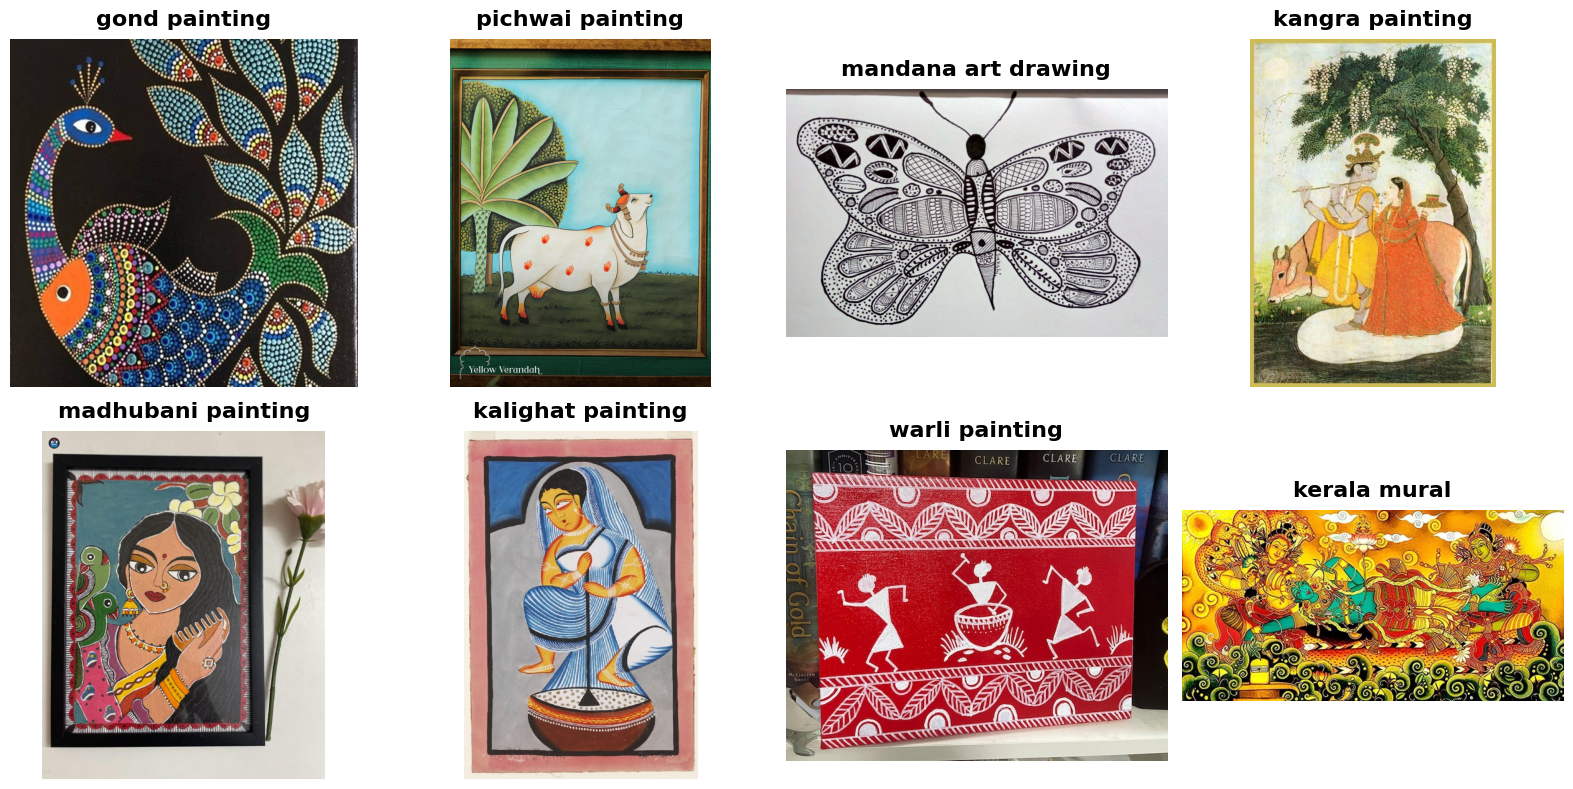

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def generate_dataset_sample_grid(data_root="data/raw", output_file="dataset_samples.png"):
    """
    Grabs one random image from each class folder and plots them in a 2x4 grid.
    Saves the figure as a high-res PNG for the research paper.
    """
    # Get all class folders (ignoring hidden files like .DS_Store)
    classes = [d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))]

    # Ensure we have exactly 8 classes for a 2x4 grid
    if len(classes) == 0:
        print("Error: No class folders found in data/raw")
        return

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, class_name in enumerate(classes[:8]): # Limit to 8 just in case
        class_dir = os.path.join(data_root, class_name)

        # Get all valid images in this class folder
        images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if images:
            # Pick a random image to represent the class
            random_image = random.choice(images)
            img_path = os.path.join(class_dir, random_image)

            # Open and display the image
            img = Image.open(img_path).convert("RGB")
            axes[i].imshow(img)
            axes[i].set_title(class_name, fontsize=16, fontweight='bold', pad=10)

        # Remove axes/ticks for a clean, academic look
        axes[i].axis('off')

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Save with 300 DPI (Standard requirement for IEEE publications)
    plt.savefig(output_file, dpi=300, bbox_inches='tight', transparent=False)
    print(f"Success! Grid saved to {output_file}")
    plt.show()

# Run the function
generate_dataset_sample_grid()

In [ ]:
import os
import json

os.makedirs("data/metadata", exist_ok=True)

class_mapping = {
    "warli painting": 0,
    "pichwai painting": 1,
    "mandana art drawing": 2,
    "madhubani painting": 3,
    "kerala mural": 4,
    "kangra painting": 5,
    "kalighat painting": 6,
    "gond painting": 7
}

with open("data/metadata/class_mapping.json", "w") as f:
    json.dump(class_mapping, f)

print("class_mapping.json created")

class_mapping.json created


In [ ]:
!ls data/metadata

class_mapping.json


In [ ]:
!python -m src.features.extract_features

Initializing feature extraction...
Processed 50 images...
Processed 100 images...
Processed 150 images...
Processed 200 images...
Processed 250 images...
Processed 300 images...
Processed 350 images...
Processed 400 images...
Processed 450 images...
Processed 500 images...
Processed 550 images...
Processed 600 images...
Processed 650 images...
Processed 700 images...
Processed 750 images...
Processed 800 images...
Processed 850 images...
Processed 900 images...

--- Extraction Complete ---
Total Images Processed: 924
Total Unique Classes: 8
DataFrame Shape: (924, 9)
Features natively dumped to => data/features.csv


In [ ]:
mkdir -p experiments

In [ ]:
!python -m src.training.train

Loading datasets...
Loaded 924 images across 8 classes
Training samples: 740
Validation samples: 184
Using device: cuda
Initializing model...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 189MB/s]
Starting training...
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/10 | Train Loss: 1.5429 | Train Acc: 51.22% | Val Loss: 3.1802 | Val Acc: 50.54%
  [✓] Best model saved
Epoch 2/10 | Train Loss: 1.2247 | Train Acc: 59.59% | Val Loss: 1.5375 | Val Acc: 47.28%
Epoch 3/10 | Train Loss: 0.9830 | Train Acc: 67.84% | Val Loss: 1.8126 | Val Acc: 44.02%
Epoch 4/10 | Train Loss: 0.7729 | Train Acc: 75.27% | Val Loss: 1.2409 | Val Acc: 61.41%
  [✓] Best model saved
Epoch 5/10 | Train Loss: 0.7407 | Train Acc: 78.24% | Val Loss: 1.2509 | Val Acc: 66.8

In [ ]:
!python -m src.models.hybrid_model

Hybrid Sequence Bound To Device -> cuda

--- Phase 1: Embedding Allocations ---

Loading Hybrid Memory Context (this sequence caches explicitly into RAM once)...
  Precomputing Record [0/924]...
  Precomputing Record [50/924]...
  Precomputing Record [100/924]...
  Precomputing Record [150/924]...
  Precomputing Record [200/924]...
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Precomputing Record [250/924]...
  Precomputing Record [300/924]...
  Precomputing Record [350/924]...
  Precomputing Record [400/924]...
  Precomputing Record [450/924]...
  Precomputing Record [500/924]...
  Precomputing Record [550/924]...
  Precomputing Record [600/924]...
  Precomputing Record [650/924]...
  Precomputing Record [700/924]...
  Precomputing Record [750/924]...
  Precomputing Record [800/924]...
  Precomputing Record [850/924]...
  Precomputing Record [900/924]...


In [ ]:
from google.colab import files
files.upload()

Saving 66ed4ff7b2ecd-scaled (1).jpeg to 66ed4ff7b2ecd-scaled (1).jpeg


{'66ed4ff7b2ecd-scaled (1).jpeg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\x06\x04\x04\x05\x04\x04\x06\x05\x05\x05\x06\x06\x06\x07\t\x0e\t\t\x08\x08\t\x12\r\r\n\x0e\x15\x12\x16\x16\x15\x12\x14\x14\x17\x1a!\x1c\x17\x18\x1f\x19\x14\x14\x1d\'\x1d\x1f"#%%%\x16\x1c),($+!$%$\xff\xdb\x00C\x01\x06\x06\x06\t\x08\t\x11\t\t\x11$\x18\x14\x18$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$\xff\xc0\x00\x11\x08\x07-\n\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x00\x07\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\xff\xc4\x00O\x10\x00\x02\x01\x03\x03\x02\x05\x02\x04\x04\x04\x04\x03\x05\x01\x11\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13"Qa\x07q\x142\x81\x91#B\xa1\xb1\x15R\xc1\xd1$3b\xe1\x16Cr4S\x82\x92\xf0\xf1\x08\x17%c\xa2&5s\xb2D\xc26\x83TU\x93d\xff\xc4\x00\x1c\x01\x00\x01\x05\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x01\x02\x03\x05\x06\x00\x07\x08\xff\xc4\x00<\x11\x00\x02\x02\x02

In [ ]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
import json

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Load class mapping
# ----------------------------
with open("data/metadata/class_mapping.json") as f:
    class_map = json.load(f)

inv_class_map = {v:k for k,v in class_map.items()}

# ----------------------------
# Load feature stats (IMPORTANT)
# ----------------------------
with open("data/metadata/feature_stats.json") as f:
    stats = json.load(f)

# ----------------------------
# Load model
# ----------------------------
from src.models.hybrid_model import HybridClassifier

model = HybridClassifier().to(device)

checkpoint = torch.load("models/hybrid_classifier.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

# ----------------------------
# Load CNN backbone
# ----------------------------
backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
backbone.fc = torch.nn.Identity()
backbone = backbone.to(device)
backbone.eval()

# ----------------------------
# Image transform
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ----------------------------
# INPUT IMAGE
# ----------------------------
image_path = "/content/Minor-Project/66ed4ff7b2ecd-scaled (1).jpeg"

image = Image.open(image_path).convert("RGB")
tensor = transform(image).unsqueeze(0).to(device)

# ----------------------------
# CNN Features
# ----------------------------
with torch.no_grad():
    cnn_features = backbone(tensor).squeeze(0)

# ----------------------------
# Handcrafted Features (FIXED)
# ----------------------------
img_cv = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

# Mean RGB (normalize same as training)
mean_r = np.mean(img_rgb[:,:,0]) / 255
mean_g = np.mean(img_rgb[:,:,1]) / 255
mean_b = np.mean(img_rgb[:,:,2]) / 255

# Color variance (STANDARDIZE)
color_variance = np.var(img_rgb)
color_variance = (color_variance - stats["color_variance"]["mean"]) / stats["color_variance"]["std"]

# Edge density (FIXED)
edges = cv2.Canny(gray,100,200)
edge_density = np.count_nonzero(edges) / (edges.shape[0]*edges.shape[1])
edge_density = (edge_density - stats["edge_density"]["mean"]) / stats["edge_density"]["std"]

# Symmetry (FIXED FORMULA)
flipped = cv2.flip(gray,1)
mse = np.mean((gray.astype("float") - flipped.astype("float"))**2)
symmetry = 1 - (mse / (255**2))
symmetry = (symmetry - stats["symmetry_score"]["mean"]) / stats["symmetry_score"]["std"]

# Entropy (FIXED)
hist = np.histogram(gray.flatten(), bins=256, range=(0,256))[0]
p = hist / np.sum(hist)
p = p[p > 0]
entropy = -np.sum(p*np.log2(p))
entropy = (entropy - stats["texture_entropy"]["mean"]) / stats["texture_entropy"]["std"]

# Combine handcrafted features
handcrafted = torch.tensor([
    mean_r, mean_g, mean_b,
    color_variance,
    edge_density,
    symmetry,
    entropy
], dtype=torch.float32).to(device)

# ----------------------------
# Combine features
# ----------------------------
hybrid_vector = torch.cat([cnn_features, handcrafted])

# ----------------------------
# Prediction
# ----------------------------
with torch.no_grad():
    output = model(hybrid_vector.unsqueeze(0))
    probs = torch.softmax(output, dim=1)
    pred = torch.argmax(probs, dim=1).item()

# ----------------------------
# Output
# ----------------------------
print("\nPrediction Probabilities:")
for i, p in enumerate(probs[0]):
    print(inv_class_map[i], float(p))

print("\nFinal Prediction:", inv_class_map[pred])
print("Confidence:", float(probs[0][pred]))


Prediction Probabilities:
warli painting 0.040698204189538956
pichwai painting 0.13197249174118042
mandana art drawing 0.11466467380523682
madhubani painting 0.047642532736063004
kerala mural 0.011763258837163448
kangra painting 0.004200570750981569
kalighat painting 0.008590438403189182
gond painting 0.6404678225517273

Final Prediction: gond painting
Confidence: 0.6404678225517273


In [ ]:
ls data/metadata

class_mapping.json  feature_stats.json



Loading Hybrid Memory Context (this sequence caches explicitly into RAM once)...
  Precomputing Record [0/924]...
  Precomputing Record [50/924]...
  Precomputing Record [100/924]...
  Precomputing Record [150/924]...
  Precomputing Record [200/924]...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Precomputing Record [250/924]...
  Precomputing Record [300/924]...
  Precomputing Record [350/924]...
  Precomputing Record [400/924]...
  Precomputing Record [450/924]...
  Precomputing Record [500/924]...
  Precomputing Record [550/924]...
  Precomputing Record [600/924]...
  Precomputing Record [650/924]...
  Precomputing Record [700/924]...
  Precomputing Record [750/924]...
  Precomputing Record [800/924]...
  Precomputing Record [850/924]...
  Precomputing Record [900/924]...
Caching Logic Resolved.


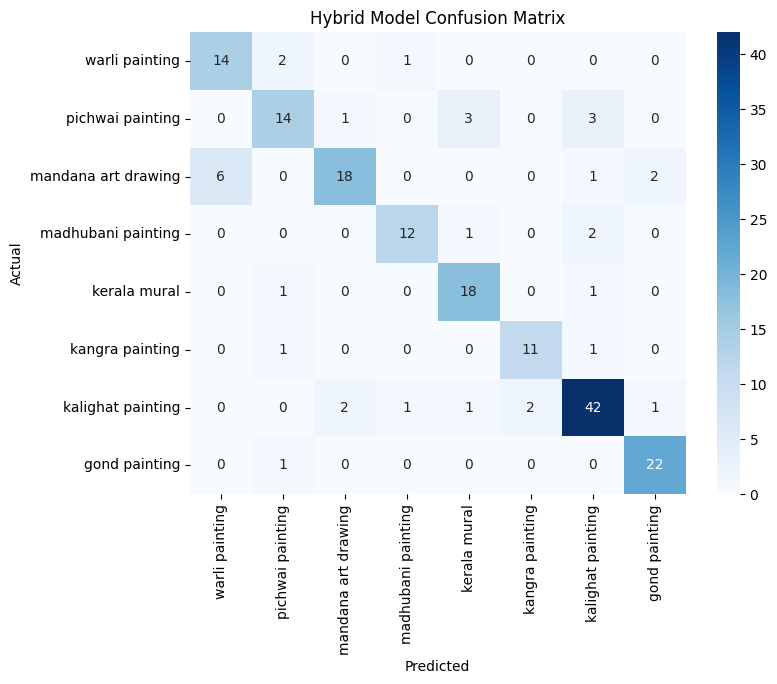

In [ ]:
import torch
import pandas as pd
import json
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.hybrid_model import HybridDataset, HybridClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load dataset
dataset = HybridDataset(
    csv_file="data/features.csv",
    class_config="data/metadata/class_mapping.json",
    device=device
)

# Split same way as training
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size], generator=generator
)

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load trained model
model = HybridClassifier().to(device)
checkpoint = torch.load("models/hybrid_classifier.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Load class mapping
with open("data/metadata/class_mapping.json") as f:
    class_map = json.load(f)

inv_class_map = {v:k for k,v in class_map.items()}

y_true = []
y_pred = []

with torch.no_grad():
    for features, labels in val_loader:

        features = features.to(device)

        outputs = model(features)
        preds = torch.argmax(outputs, dim=1).cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

labels = [inv_class_map[i] for i in range(len(inv_class_map))]

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hybrid Model Confusion Matrix")
plt.show()

In [ ]:
import numpy as np

cm = np.array(cm)

class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i,acc in enumerate(class_accuracy):
    print(inv_class_map[i], ":", round(acc*100,2), "%")

warli painting : 82.35 %
pichwai painting : 66.67 %
mandana art drawing : 66.67 %
madhubani painting : 80.0 %
kerala mural : 90.0 %
kangra painting : 84.62 %
kalighat painting : 85.71 %
gond painting : 95.65 %


In [ ]:
import torch
import pandas as pd
import json
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from src.models.hybrid_model import HybridDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = HybridDataset(
    csv_file="data/features.csv",
    class_config="data/metadata/class_mapping.json",
    device=device
)

X = []
y = []

for features, label in dataset:
    X.append(features.cpu().numpy())
    y.append(label)

import numpy as np
X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)


Loading Hybrid Memory Context (this sequence caches explicitly into RAM once)...
  Precomputing Record [0/924]...
  Precomputing Record [50/924]...
  Precomputing Record [100/924]...
  Precomputing Record [150/924]...
  Precomputing Record [200/924]...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Precomputing Record [250/924]...
  Precomputing Record [300/924]...
  Precomputing Record [350/924]...
  Precomputing Record [400/924]...
  Precomputing Record [450/924]...
  Precomputing Record [500/924]...
  Precomputing Record [550/924]...
  Precomputing Record [600/924]...
  Precomputing Record [650/924]...
  Precomputing Record [700/924]...
  Precomputing Record [750/924]...
  Precomputing Record [800/924]...
  Precomputing Record [850/924]...
  Precomputing Record [900/924]...
Caching Logic Resolved.
Feature Matrix Shape: (924, 519)


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.07987923 0.04865642]


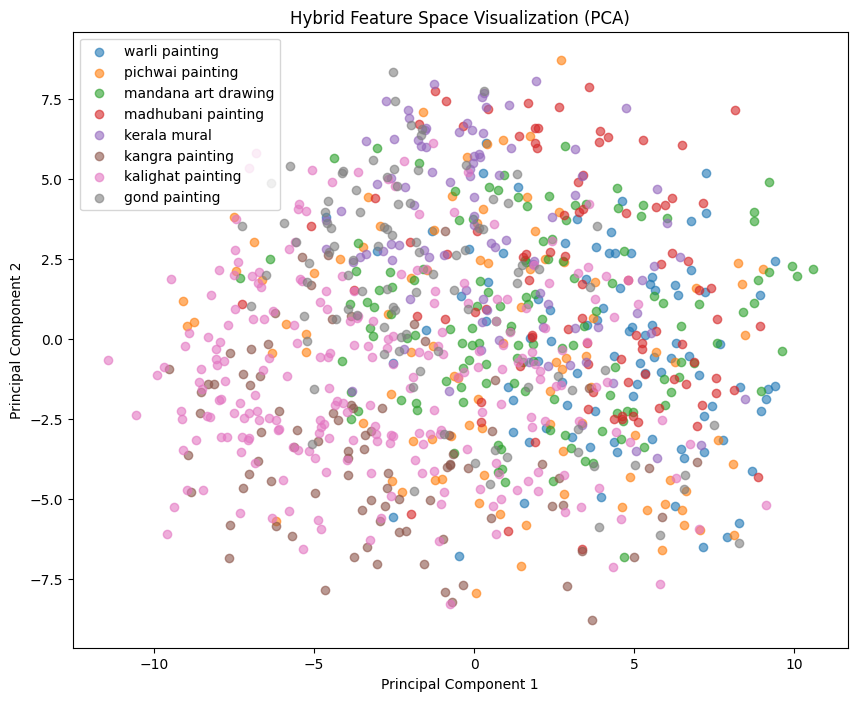

In [ ]:
import matplotlib.pyplot as plt
import json

with open("data/metadata/class_mapping.json") as f:
    class_map = json.load(f)

inv_map = {v:k for k,v in class_map.items()}

plt.figure(figsize=(10,8))

for i in range(len(inv_map)):
    idx = y == i
    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=inv_map[i],
        alpha=0.6
    )

plt.legend()
plt.title("Hybrid Feature Space Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
print(class_map)

{'warli painting': 0, 'pichwai painting': 1, 'mandana art drawing': 2, 'madhubani painting': 3, 'kerala mural': 4, 'kangra painting': 5, 'kalighat painting': 6, 'gond painting': 7}
